## Setup

In [1]:
import json

#get params
with open("./params.json", mode = "r", encoding = "utf-8") as f:
    data = json.load(f)
    seed_vals = data["seed_vals"]
    ensemble_root_path = data["ensemble_root_path"]
    dataset_path_test_stream_windowed = data["dataset_path"]["test"]["stream"]["windowed"]
    dataset_path_test_stream_full = data["dataset_path"]["test"]["stream"]["full"]
    dataset_path_test_reversal_windowed = data["dataset_path"]["test"]["reversal"]["windowed"]
    dataset_path_test_reversal_full = data["dataset_path"]["test"]["reversal"]["full"]
    stats_path = data["stats_path"]
    num_single_sample_timesteps = data["num_single_sample_timesteps"]
    input_window_length = data["input_window_length"]
    label_window_length = data["label_window_length"]
    valid_length = input_window_length + label_window_length
    input_features = data["input_features"]
    label_features = data["label_features"]
    extra_features = data["extra_features"]
    num_label_features = len(label_features)
    window_stride = data["window_stride"]
    num_datapoints_per_timeseries = len(
        list(
            range(
                0, num_single_sample_timesteps - (input_window_length + label_window_length) + 1, window_stride
            )
        )
    )
    # num_datapoints_per_timeseries = 1 + (num_single_sample_timesteps - (input_window_length + label_window_length) + 1) // window_stride

    seed_val = 0

    # Use for kdeplot inference
    batch_size = data["batch_size"]

In [2]:
import torch
import random
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(seed_val)
random.seed(seed_val)
np.random.seed(seed_val)

In [3]:
# from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import ipywidgets as widgets
import polars as pl

from utils.pipeline.Model import TimeSeriesHuggingFaceTransformer
# from utils.pipeline.Data import get_mean_std_respected_temporal, WindowedIterableDataset, read_stats
from utils.pipeline.Data import InferenceAnalysisDataset, WindowedDataset
from utils.pipeline.Run import forward_pass

In [4]:
# stats = pl.read_csv(stats_path)

# df_test = InferenceAnalysisDataset(
#     windowed_dataset_path = dataset_path_test_windowed,
#     full_dataset_path = dataset_path_test_full,
#     index_full_update_len = num_datapoints_per_timeseries
# )

### REVERSALS ###

stats = pl.read_csv(stats_path)

df_test = InferenceAnalysisDataset(
    windowed_dataset_path = dataset_path_test_reversal_windowed,
    full_dataset_path = dataset_path_test_reversal_full,
    index_full_update_len = num_datapoints_per_timeseries
)

## Prediction

In [5]:
model_paths = [
    f"{ensemble_root_path}/22/T5-{input_window_length}-{label_window_length}-{window_stride}-{val}.pt" for val in seed_vals
]

In [ ]:
num_timeseries = 40
first_window = 69

original_reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)

reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)

# good_reversal_probs_old = pd.DataFrame(
#     index=range(num_timeseries),
#     columns=[str(j) for j in range(first_window, 80)],
# )

good_reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)

with torch.no_grad():
    #timeseries idx loop
    for i in range(num_timeseries):
        #window_idx loop
        for j in range(first_window, 80):
            target_timeseries_idx = i
            selected_window_idx = j

            data_idx = target_timeseries_idx * num_datapoints_per_timeseries + selected_window_idx
            window_x, window_y, x_labels, extra_full = df_test[data_idx]
            x_labels = x_labels.unsqueeze(0)
            extra_full = extra_full.unsqueeze(0)
            batch_x = window_x.unsqueeze(0).to(device)
            batch_y = window_y.unsqueeze(0).to(device)

            x = list(range(num_single_sample_timesteps))

            #feature_idx = label_features.index(feature)
            #feature_label = batch_y[0, :, feature_idx].cpu()

            all_preds = torch.zeros((len(model_paths),) + batch_y.shape)
            all_attns = torch.zeros((len(model_paths),) + (label_window_length, input_window_length))

            losses = np.zeros(10)

            for model_idx, path in enumerate(model_paths):
                #grab a model
                criterion = torch.nn.L1Loss()
                model = torch.load(path, map_location=device, weights_only = False).to(device)
                model.eval()

                #forward pass of the model
                outputs = forward_pass(
                    model = model,
                    batch_x = batch_x,
                    device = device,
                    extract_attention = True
                )
                #grab the predictions
                preds = outputs.logits

                #calculate loss
                loss = criterion(preds, batch_y)
                losses[model_idx] = loss.item()
                #print(f"Single Test Loss: {loss.item():.6f}")

                #put preds in tensor
                all_preds[model_idx, :, :, :] = preds

                #put attention values in tensor
                all_attns[model_idx, :, :] = model.get_average_attention_values()

                del model
                torch.cuda.empty_cache()

            #get predictions and labels
            #feature_pred = all_preds[:, 0, :, feature_idx].cpu()
            #feature_x_labels = x_labels[0, :, feature_idx]
            #extra_values = extra_full[0, :, 0] / 50

            #un-normalize the predictions and labels
            #feature_label = (feature_label * stats[0, f"{feature}_std"]) + stats[0, f"{feature}_mean"]
            #feature_pred = (feature_pred * stats[0, f"{feature}_std"]) + stats[0, f"{feature}_mean"]

            #mean_feature_preds = feature_pred.mean(dim = 0)
            #std_feature_preds = feature_pred.std(dim = 0)

            # Reversal probability
            u_idx = label_features.index("u_list")
            first_timesteps = all_preds[:, 0, 0, u_idx].numpy()
            last_timesteps = all_preds[:, 0, -1, u_idx].numpy()
            late_but_not_last_timesteps = all_preds[:, 0, max((78-j)*5, 0), u_idx].numpy()
            
            count_pred_reversal_original = np.sum(np.sign(first_timesteps) != np.sign(last_timesteps))
            count_pred_reversal = np.sum(np.sign(-1) == np.sign(last_timesteps))
            # if(j >= 78):
            #     count_pred_good_reversal_old = np.sum(np.sign(1) != np.sign(last_timesteps))
            # else:
            #     count_pred_good_reversal_old = np.sum(np.sign(late_but_not_last_timesteps) != np.sign(last_timesteps))
            count_pred_good_reversal = np.sum((last_timesteps < 0) & (losses < 1))

            original_reversal_prob = (count_pred_reversal_original / len(model_paths)) * 100
            reversal_prob = (count_pred_reversal / len(model_paths)) * 100
            #good_reversal_prob = (count_pred_good_reversal_old / len(model_paths)) * 100
            good_reversal_prob = (count_pred_good_reversal /len(model_paths)) * 100

            original_reversal_probs.iloc[i, j-first_window] = original_reversal_prob
            reversal_probs.iloc[i, j-first_window] = reversal_prob
            #good_reversal_probs_old.iloc[i, j-first_window] = good_reversal_prob
            good_reversal_probs.iloc[i, j-first_window] = good_reversal_prob


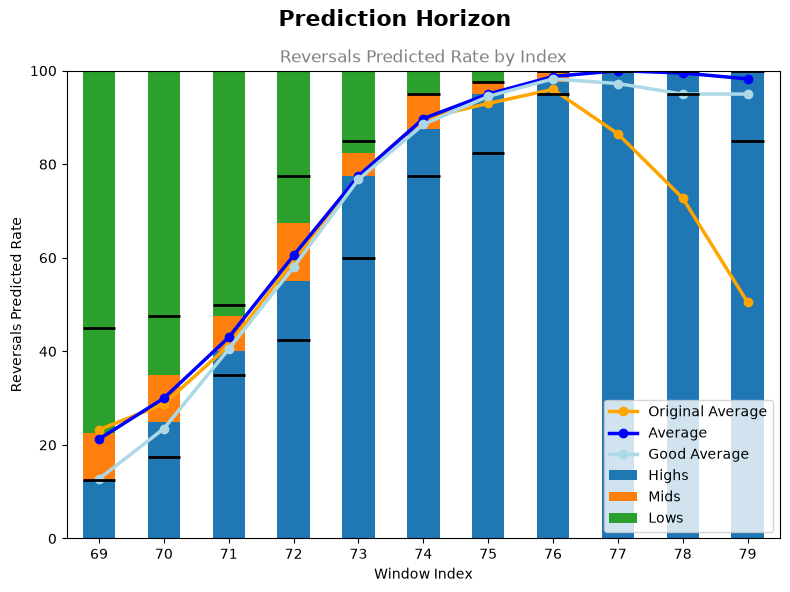

In [36]:
num_windows = 80 - first_window

counts_100 = (reversal_probs == 100).sum(axis=0).to_numpy()/np.full(num_windows, 0.4)
counts_high = (reversal_probs >= 80).sum(axis=0).to_numpy()/np.full(num_windows, 0.4)
counts_low = (reversal_probs <= 20).sum(axis=0).to_numpy()/np.full(num_windows, 0.4)
counts_0 = (reversal_probs == 0).sum(axis=0).to_numpy()/np.full(num_windows, 0.4)
counts_mid = (np.full(num_windows, 100) - counts_high - counts_low)

original_averages = original_reversal_probs.mean().to_numpy()
column_averages = reversal_probs.mean().to_numpy()
#good_averages_old = good_reversal_probs_old.mean().to_numpy()
good_averages = good_reversal_probs.mean().to_numpy()

tick_100_y = counts_100
tick_0_y = 100 - counts_0

data = {
    'Index': reversal_probs.columns,
    'Highs': counts_high,
    'Mids': counts_mid,
    'Lows': counts_low
}
df = pd.DataFrame(data).set_index('Index')

fig, ax = plt.subplots(figsize=(8, 6))
df.plot(kind='bar', stacked=True, ax=ax, width=0.5)

bar_width = 0.5
xticks = ax.get_xticks()
ax.hlines(tick_100_y, xticks - bar_width/2, xticks + bar_width/2, color='black', linewidth=2, zorder=5)
ax.hlines(tick_0_y, xticks - bar_width/2, xticks + bar_width/2, color='black', linewidth=2, zorder=5)

# 4. Plot the line graph on the secondary axis
# Note: Use ax1.get_xticks() to perfectly align the line points with the bar centers
ax.plot(ax.get_xticks(), original_averages, color='orange', marker='o', linewidth=2.5, label='Original Average')
ax.plot(ax.get_xticks(), column_averages, color='blue', marker='o', linewidth=2.5, label='Average')
#ax.plot(ax.get_xticks(), good_averages_old, color='blue', marker='o', linewidth=2.5, label='Good Average Old')
ax.plot(ax.get_xticks(), good_averages, color='lightblue', marker='o', linewidth=2.5, label='Good Average')

ax.legend(loc='lower right')

plt.suptitle('Prediction Horizon', fontsize=16, fontweight='bold')
plt.title('Reversals Predicted Rate by Index', fontsize=12, color='gray')
plt.xlabel('Window Index')
plt.ylabel('Reversals Predicted Rate')
plt.xticks(rotation=0) # Keep X labels horizontal
plt.tight_layout()
plt.show()